# A Basic Overview

This tutorial is designed to give users a basic introduction to the core parts of dLux. We will cover how to create an optical system and its psf, how to work with dLux objects, and show a basic optimisation workflow. It will be broken down into the following sections:

1. Building an Optical System
2. Simulating Data
3. Basic Optimisation Workflow

In [ ]:
# Basic imports
import jax.numpy as np
import jax.random as jr

# Optimisation imports
import equinox as eqx
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import CenteredNorm

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

---

## 1. Building an Optical System

Lets start by taking a look at how to build an optical system in dLux, we will focus on the `AngularOpticalSystem` class as it is the most-common for astronomical problems. As mentioned above, dLux optical systems are built from a series of layers that operate sequentially on a wavefront. Each layer is designed to represent a specific transformation to the wavefront, such as encountering an aperture, phase aberration, or propagating to focus. By combining these layers together, we can build up complex optical systems that can model real-world telescopes and instruments.

Beyond the layers themselves, we also need to define a few other properties of the optical system. In order to construct at wavefront at the aperture of the telescope we need to define its diameter, and the number of pixels used to represent the wavefront. To propagate the wavefront to the focal plane, we also need to define the pixel scale of the PSF, and the number of pixels used to represent the PSF.

For this problem, we will build a Euclid-like optical system, since the asymmetry of its aperture makes recovering even Zernike modes easy! Rather than looking at how to build this aperture from scratch here (since we have tutorials on that [here](https://louisdesdoigts.github.io/dLux/tutorials/howtos/custom_apertures/)), we will use a helper function that constructs the aperture for us, imported from the local `optics.py` file. Using this optical system we will model an PSF with optical aberrations and show how we can recover these aberrations directly. 

Lets look at how to build this optical system, starting by getting the different pieces we need together

In [2]:
# Define our wavefront properties
wf_npix = 256  # Number of pixels in the wavefront
diameter = 1.0  # Diameter of the wavefront, meters

# Define our detector properties
psf_npix = 64  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds

# Generate a euclid-like aperture and Zernike
aperture, basis = dlu.euclid_like(
    npixels=wf_npix,
    diameter=1.1,
    oversample=5,  # Oversampling factor
    secondary_diameter=0.25,  # Diameter of the secondary
    spider_width=0.075,  # Width of the spiders
    zernike_nolls=np.arange(4, 22)  # Skip piston tip tilt
)

# Normalise the basis to nm and generate some random coefficients
basis *= 1e-9
coeffs = 25 * jr.normal(jr.key(0), basis.shape[0])

Now that we have the bits we need to define our optical system, lets see how we can actually construct it with our variables and layers. There are two layers we are going to need here, the `TransmissiveLayer` and the `BasisLayer`. These will be used to apply our aperture and our optical aberrations respectively. 

We define these layers using a list, ordered in the sequence in which we would like to apply them. While we can pass in the layer directly, its helpful to pass in a tuple pair of `(key, layer)`, as this lets us specify a key that we can use to reference that layer directly, giving us a nicer way to interact with our resutling `OpticalSystem` object.

In [3]:
# Define our aperture layer - note the normalise tells the optical system to normalise
# the wavefront at this layer.
aperture = dl.layers.TransmissiveLayer(transmission=aperture, normalise=True)

# Define our aberrations layer, this will apply our basis as an OPD to the wavefront
aberrations = dl.layers.BasisLayer(basis=basis, coefficients=coeffs)

# Define the optical layers
layers = [
    ("aperture", aperture),
    ("aberrations", aberrations),
]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix, 
    diameter=diameter, 
    layers=layers, 
    psf_npixels=psf_npix, 
    psf_pixel_scale=psf_pixel_scale
)

# Examine the optics object
print(optics)

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False)
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


Great, as we can see, we now have an optical system object! As you can see dLux objects have pretty-printing syntax (inherited from Equinox) that gives us a nice summary of the object and its properties. This becomes very helpful to understand, manipulate, and work with our classes and highlights one of the core ethos' of dLux - transparency. We want users to understand what is going on under the hood, never do anything 'magic' or hidden, and to be able to interact with it in a way that is intuitive and easy to understand. Now lets see how we can use it!


With our optical system defined, we can now propagate a wavefront through it to get a PSF. The core function for this is the `propagate` method, letting us throw whatever wavelengths we would like through the system. Lets see what this looks like in practice.

In [4]:
# Define the spectral properties of our source for the propagation
wavels = 1e-6 * np.linspace(0.75, 1, 5)
weights = np.linspace(0.5, 1, len(wavels))
weights /= weights.sum()

# Set the position of the source on-sky
position = dlu.arcsec2rad(np.array([0.1, 0.05]))

# Propagate through the system to get the PSF
psf = optics.propagate(wavels, offset=position, weights=weights)

Now lets take a quick look at our aperture, OPD, and PSF to see what we are working with.

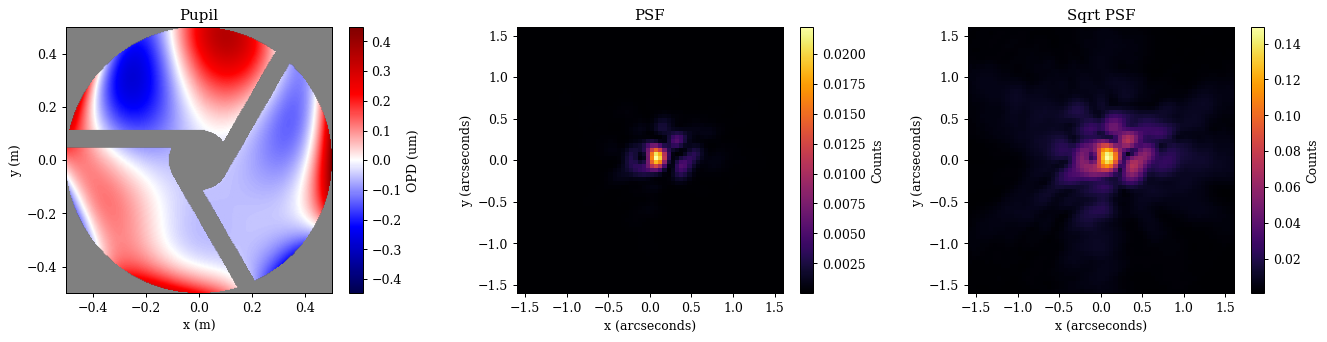

In [5]:
## COLLAPSE: Plotting
# Get the aperture and OPD for visualisation
opd = 1e6 * optics.aberrations.eval_basis()  # Normalise to microns
pupil = opd.at[optics.transmission < 0.5].set(np.nan)

# Get the extents for visualisation
ap_extent = dlu.imshow_extent(optics.diameter)
psf_extent = dlu.imshow_extent(optics.fov)

# Plot the results
plt.figure(figsize=(15, 3.75))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(pupil, seismic, norm=CenteredNorm(), extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Pupil", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(psf**0.5, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Sqrt PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

---

## 2. Simulating Data

Now that we have a psf, we can use it to simulate some data that we will recover the optical aberrations from. We will do this using the jax.random module to add some noise. This is important when simulating systems as otherwise our model can represent our data to machine precision and the optimisation will never really converge!

To make this a realistic simulation we need to add some flux to our PSF, as well as some read noise from the detector. Since we already normalised our optical system at the aperture layer, our PSF represents the probability distribution of one photon passing through the aperture. This means that our recovered fluxes will represent the amount of photons passing through the aperture, so we can map this to a real flux using the collecting area of the aperture. Also, since a non-zero amount of light will diffract beyond the edge of the detector, our PSF sum will always be less than zero, which is representative of the real world where we never capture all the light from a source.



In [6]:
# Generate the illuminance and define the read noise
flux = 5e5
illumination = flux * psf  # Put 1 million photons through the aperture
read_noise = 10.0  # 10 electrons of read noise

# Define the number of images we want to simulate
n_frames = 100

# Draw the photons and read noise from the appropriate distributions
shape = (n_frames, *illumination.shape)
photons = jr.poisson(jr.key(1), illumination, shape)
read_electrons = read_noise * jr.normal(jr.key(2), shape)

# Create the data by defining the image as the sum of the photons and the read noise
images = photons + read_electrons
data = images.mean(0)
error = images.std(0) / np.sqrt(n_frames)

Now that we have our PSF and data, lets visualise this system. This will show how we can extract our aperture transmission and our applied OPDs from the optical system for visualisation purposes!

??? "Accessing Parameters"
    Note that dLux _raises parameters_ from the layers up to the optical system object - Thats what the layers key is for! This means that we can access the parameters of the layers directly from the optical system rather than referencing all the way through the object. Lets say we wanted to access the aperture transmission array. Normally, we would have to reference it through the entire system like `optics.layers['aperture'].transmission`, but since the parameters are raised, we can just do `optics.aperture.transmission`! This is a small thing, but it makes working with the system much nicer and more intuitive. As we will see soon, this also makes optimising these objects with zodiax much nicer.

    dLux will also search through the layers for the attribute that we want, so we can just do `optics.transmission`, however, this can lead to issues if we have multiple layers with the same attribute, so make sure you know where your parameters are coming from if you use this method!

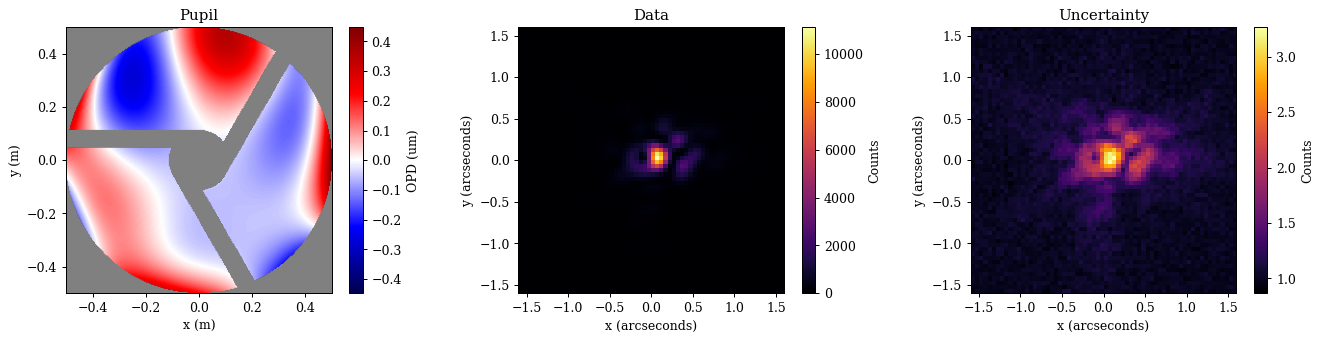

In [7]:
## COLLAPSE: Plotting
# Get the aperture and OPD for visualisation
opd = 1e6 * optics.aberrations.eval_basis() # Normalise to microns
pupil = opd.at[optics.transmission < 0.5].set(np.nan)

# Get the extents for visualisation
ap_extent = dlu.imshow_extent(optics.diameter)
psf_extent = dlu.imshow_extent(optics.fov)

# Plot the results
plt.figure(figsize=(15, 3.75))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(pupil, seismic, norm=CenteredNorm(), extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Pupil", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(data, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Data", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(error ** 0.5, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Uncertainty", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

---

## 3. A Basic Optimisation Workflow

Okay this looks good! Now lets see how we can use our model and this data to recover the stellar position and flux, while also recovering the optical aberrations! To do this, we first need to set our define our likelihood function and set the initial values of our model. For our likelihood function we will use the z-score, which is a standardised measure of the difference between our model and the data. Lets see how to do that quickly.

In [8]:
def model_fn(params, optics):
    """Predict the data given the current parameters and model"""
    # Unpack and cast the parameters to the correct units
    flux = 10 ** params["flux"]
    position = dlu.arcsec2rad(params["position"])

    # Update the optical system with the current parameters
    optics = optics.set(coefficients=params["z-coeffs"])

    # Predict the PSF
    return flux * optics.propagate(wavels, position, weights=weights)


@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, optics, data, error):
    """Basic loss function"""
    psf = model_fn(params, optics)
    return np.square(zdx.z_score(psf, data, error)).mean()

Great now lets do some optimisation. Here we need to use use a staged optimisation strategy to make sure we recover our parameters correctly, as well as tune the learning rates for each parameter. This is simply the most direct approach, but there are lots of other ways to tackle this problem! For a more complete tutorial on optimisation within the zodiax framework, check out [this tutorial](https://louisdesdoigts.github.io/zodiax/optimisation_tools/). For now, we are going to assume that you have been through that tutorial (although don't worry if you haven't, its all very straight forwards and you should be able to follow without any trouble). Lets see how to set up this likelihood function and optimisation in practice.

In [9]:
# Set up the initial parameters
params = {
    "z-coeffs": np.zeros_like(coeffs),
    "flux": np.log10(data.sum()),
    "position": np.zeros(2),
}

# Set up the optimisers for each parameter
# Note we use the delay function to delay the optimisation of certain parameters
optimisers = {
    "position": optax.sgd(zdx.delay(5e-8, 0), momentum=0.5),
    "z-coeffs": optax.sgd(zdx.delay(2e-1, 10), momentum=0.5),
    "flux": optax.sgd(zdx.delay(1e-6, 20), momentum=0.5),
}
optim, state = zdx.map_optimisers(params, optimisers)

# Now we can run a simple optimisation loop
epochs = 100
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_fn(params, optics, data, error)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{np.log10(loss):.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

  0%|          | 0/100 [00:00<?, ?it/s]

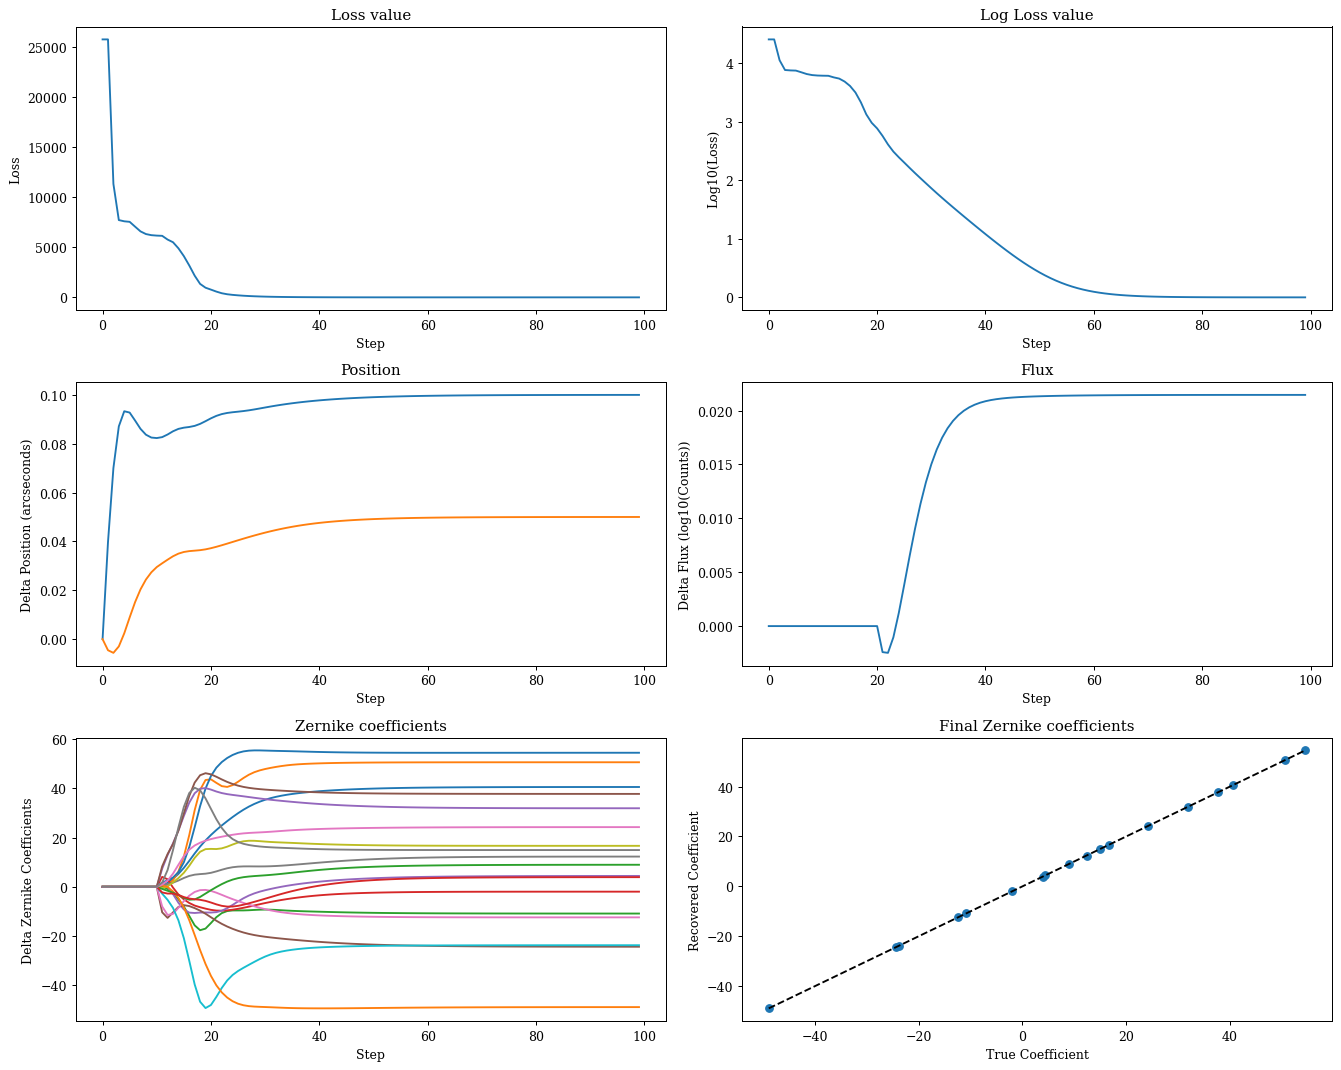

In [10]:
## COLLAPSE: Plotting
# Map the parameter history to arrays for plotting
values = {}
for param in params.keys():
    value = np.array([params[param] for params in params_history])
    values[param] = (value - value[0]).reshape(epochs, -1)

# Plot the losses
plt.figure(figsize=(15, 12))
ax = plt.subplot(3, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(3, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Log Loss value", xlabel="Step", ylabel="Log10(Loss)")

ax = plt.subplot(3, 2, 3)
ax.plot(values["position"])
ax.set(title="Position", xlabel="Step", ylabel="Delta Position (arcseconds)")

ax = plt.subplot(3, 2, 4)
ax.plot(values["flux"])
ax.set(title="Flux", xlabel="Step", ylabel="Delta Flux (log10(Counts))")

ax = plt.subplot(3, 2, 5)
ax.plot(values["z-coeffs"])
ax.set(title="Zernike coefficients", xlabel="Step", ylabel="Delta Zernike Coefficients")

ax = plt.subplot(3, 2, 6)
ax.scatter(coeffs, values["z-coeffs"][-1])
ax.plot([coeffs.min(), coeffs.max()], [coeffs.min(), coeffs.max()], "k--", label="1:1")
ax.set(title="Final Zernike coefficients", ylabel="Recovered Coefficient", xlabel="True Coefficient")

plt.tight_layout()
plt.show()

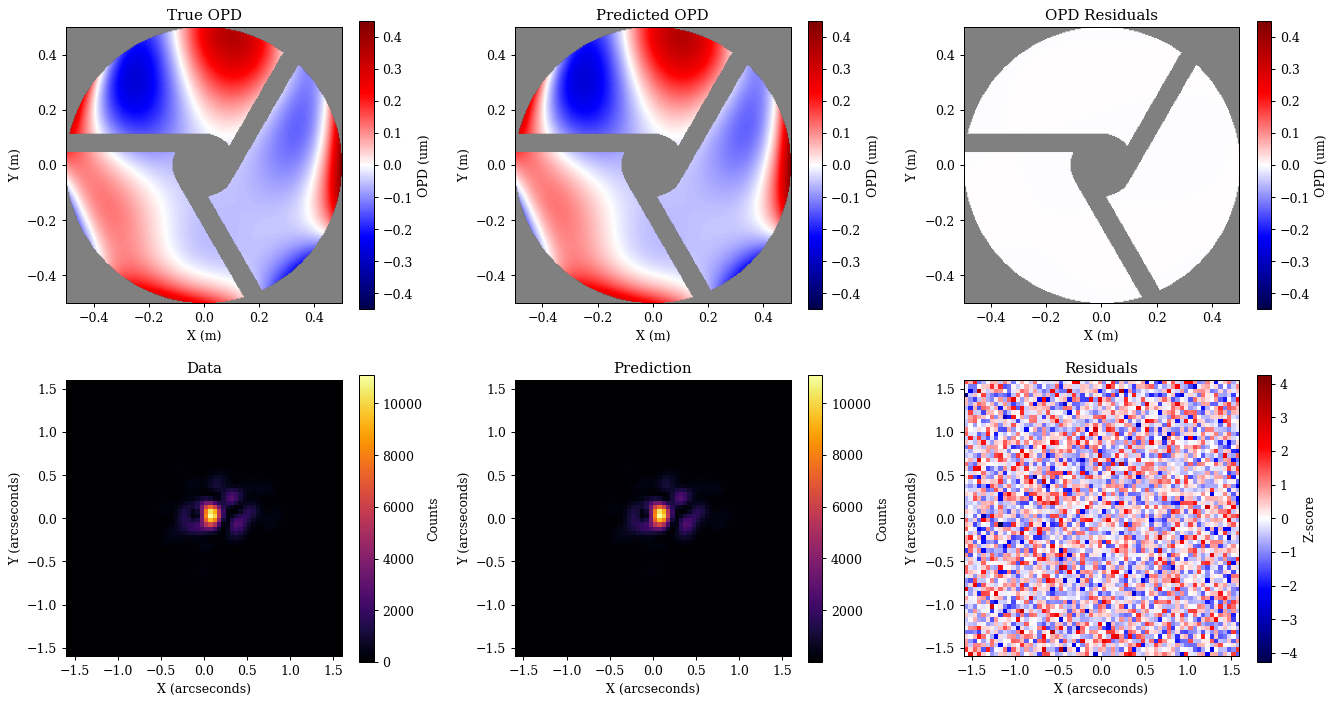

In [11]:
## COLLAPSE: Plotting
# Get the aperture and OPD for visualisation
pred_opd = 1e6 * optics.set(coefficients=params["z-coeffs"]).aberrations.eval_basis()
pred_pupil = pred_opd.at[optics.transmission < 0.5].set(np.nan)
pupil_residuals = pred_pupil - pupil
v = np.nanmax(np.abs(np.array([pupil, pred_pupil])))

# Get our predicted data for the final parameters
pred = model_fn(params, optics)
z_score = zdx.z_score(pred, data, error)

plt.figure(figsize=(15, 8))
ax = plt.subplot(2, 3, 1)
im = ax.imshow(pupil, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="True OPD", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 2)
im = ax.imshow(pred_pupil, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Predicted OPD", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 3)
im = ax.imshow(pupil_residuals, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="OPD Residuals", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 4)
im = ax.imshow(data, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Data", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

ax = plt.subplot(2, 3, 5)
im = ax.imshow(pred, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Prediction", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

ax = plt.subplot(2, 3, 6)
im = ax.imshow(z_score, seismic, norm=CenteredNorm(), extent=psf_extent)
plt.colorbar(im, ax=ax, label="Z-score")
ax.set(title="Residuals", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

plt.tight_layout()
plt.show()

Great, as we can see we have correctly recovered all of our parameters, and there is no more information to extract from the data! This is a good sign that our model is correct and that we have done everything right. 